#### Imports and Setups

In [148]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
from IPython.display import display
import csv
import os
from pathlib import Path
import numpy as np
from bs4 import BeautifulSoup
import requests

In [149]:
# setting figure directory 
fig_dir = Path.cwd().parent / "outputs" / "figures" / "tranco_list" 
fig_dir.mkdir(parents=True, exist_ok=True)

#### Loading Data

In [150]:
# loading dependency parquet files
base_dir = Path.cwd().parent / "data" / "result" / "tranco_list"

try:
    gTLD_summary_df = pd.read_parquet(base_dir / "gTLD_domains_dependency_no_parent.parquet")
    
    ccTLD_summary_df = pd.read_parquet(base_dir / "ccTLD_domains_dependency_no_parent.parquet")
    
    genTLD_summary_df = pd.read_parquet(base_dir / "gen_resTLD_domains_dependency_no_parent.parquet")
    
    infTLD_summary_df = pd.read_parquet(base_dir / "infrTLD_domains_dependency_no_parent.parquet")
    
    sponTLD_summary_df = pd.read_parquet(base_dir / "sponTLD_domains_dependency_no_parent.parquet")

    domain_with_parent = pd.read_parquet(base_dir / "domain_with_parent_rel.parquet")
    
except Exception as e:
    print(f"failed: {e}")

In [151]:
# loading categorized names
base_dir = Path.cwd().parent / "data" / "names"
try:
    categorized_names_df = pd.read_parquet(base_dir / "tranco_categorized_names.parquet")
except Exception as e:
    print(f"failed: {e}")   

##### Checking if data loaded correctly

In [152]:
len(gTLD_summary_df)

586943

In [153]:
genTLD_summary_df.head(2)

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies
0,link-988betgcr.pro,1,1,2,1.0,2,"[treasure.ns.cloudflare.com, fred.ns.cloudflar...","[{'name_server_count': 1, 'name_servers': ['tr...","[{'source': 'link-988betgcr.pro', 'target_zone..."
1,desabet.pro,1,1,2,1.0,2,"[apollo.ns.cloudflare.com, crystal.ns.cloudfla...","[{'name_server_count': 1, 'name_servers': ['ap...","[{'source': 'desabet.pro', 'target_zone': None..."


In [88]:
domain_with_parent.head()

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,parent,short_path_size_via_parent,long_path_size_via_parent,available_paths_via_parent,average_path_size_via_parent,parent_TCB,TCB_with_parent,all_parent_unique_ns,parent_path_rows
0,apostille.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare....","[{'domain': 'apostille.mygov.bd', 'name_server...","[{'side': 'child', 'source': 'apostille.mygov....",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov...","[{'domain': 'mygov.bd', 'name_server_count': 1..."
1,www.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare....","[{'domain': 'www.mygov.bd', 'name_server_count...","[{'side': 'child', 'source': 'www.mygov.bd', '...",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov...","[{'domain': 'mygov.bd', 'name_server_count': 1..."


##### Checking for duplicates in Data

In [89]:
# check if it has duplicate item on domain column for all dataframes

print(f'domain_with_parent has {domain_with_parent["domain"].duplicated().sum()} duplicates')
print(f'gTLD_summary_df has {gTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'ccTLD_summary_df has {ccTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'genTLD_summary_df has {genTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'infTLD_summary_df has {infTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'sponTLD_summary_df has {sponTLD_summary_df["domain"].duplicated().sum()} duplicates')


domain_with_parent has 0 duplicates
gTLD_summary_df has 0 duplicates
ccTLD_summary_df has 0 duplicates
genTLD_summary_df has 0 duplicates
infTLD_summary_df has 0 duplicates
sponTLD_summary_df has 0 duplicates


##### test to be locked at later _check unresolved

In [92]:
group_map = {
    "gTLD": {
        "types": ["generic"],
        "summary_df": gTLD_summary_df,
    },
    "ccTLD": {
        "types": ["country-code"],
        "summary_df": ccTLD_summary_df,
    },
    "gen_resTLD": {
        "types": ["generic-restricted"],
        "summary_df": genTLD_summary_df,
    },
    "infraTLD": {
        "types": ["infrastructure"],
        "summary_df": infTLD_summary_df,
    },
    "sponTLD": {
        "types": ["sponsored"],
        "summary_df": sponTLD_summary_df,
    }
}

In [93]:
unresolved_rows = []

for group_name, info in group_map.items():

    expected_domains = set(
        categorized_names_df[
            categorized_names_df["type"].isin(info["types"])
            & (categorized_names_df["p_status"] != "NOT_TLD")
        ]["domain"]
        .dropna()
        .astype(str)
        .str.lower()
    )

    resolved_domains = set(
        info["summary_df"]["domain"]
        .dropna()
        .astype(str)
        .str.lower()
    )

    unresolved_domains = expected_domains - resolved_domains

    for domain in unresolved_domains:
        unresolved_rows.append({
            "domain": domain,
            "type": group_name
        })

unresolved_df = pd.DataFrame(unresolved_rows)

In [94]:
unresolved_df.head()

,domain,type
0,magicgarden.wiki,gTLD
1,augahi.net,gTLD
2,ca61southerns.shop,gTLD
3,redenexus.top,gTLD
4,cbaservers.com,gTLD


In [95]:
unresolved_df.groupby("type").size().sort_values(ascending=False)

type
gTLD          32858
ccTLD         20679
gen_resTLD      388
sponTLD         226
dtype: int64

In [96]:
for group_name, info in group_map.items():
    expected_count = categorized_names_df[
        categorized_names_df["type"].isin(info["types"])
        & (categorized_names_df["p_status"] != "NOT_TLD")
    ]["domain"].nunique()

    resolved_count = info["summary_df"]["domain"].nunique()

    unresolved_count = unresolved_df[unresolved_df["type"] == group_name]["domain"].nunique()

    print(group_name, {
        "expected": expected_count,
        "resolved": resolved_count,
        "unresolved": unresolved_count
    })

gTLD {'expected': 619801, 'resolved': 586943, 'unresolved': 32858}
ccTLD {'expected': 367652, 'resolved': 346973, 'unresolved': 20679}
gen_resTLD {'expected': 5718, 'resolved': 5330, 'unresolved': 388}
infraTLD {'expected': 4, 'resolved': 4, 'unresolved': 0}
sponTLD {'expected': 6822, 'resolved': 6596, 'unresolved': 226}


In [97]:
unresolved_df = unresolved_df.sort_values(["type", "domain"]).reset_index(drop=True)

unresolved_df.to_parquet(
    base_dir / "unresolved_domains_by_type.parquet",
    index=False
)

In [98]:
rows = []

for group_name, info in group_map.items():

    expected_count = categorized_names_df[
        categorized_names_df["type"].isin(info["types"])
        & (categorized_names_df["p_status"] != "NOT_TLD")
    ]["domain"].nunique()

    resolved_count = info["summary_df"]["domain"].nunique()

    unresolved_count = unresolved_df[
        unresolved_df["type"] == group_name
    ]["domain"].nunique()

    rows.append({
        "group_code": group_name,
        "expected": expected_count,
        "resolved": min(resolved_count, expected_count),
        "unresolved": unresolved_count,
        "resolved_extra": max(resolved_count - expected_count, 0)
    })

plot_df = pd.DataFrame(rows)

In [99]:
plot_df.loc[len(plot_df)] = {
    "group_code": "Total",
    "expected": plot_df["expected"].sum(),
    "resolved": plot_df["resolved"].sum(),
    "unresolved": plot_df["unresolved"].sum(),
    "resolved_extra": plot_df["resolved_extra"].sum()
}

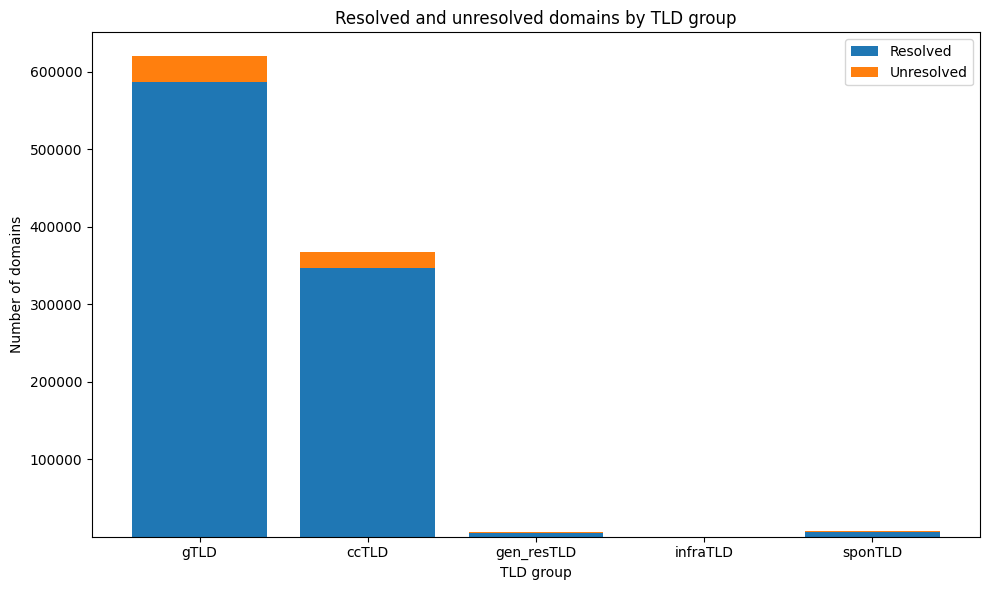

In [100]:
plot_data = plot_df[plot_df["group_code"] != "Total"].copy()

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(plot_data))

ax.bar(
    x,
    plot_data["resolved"],
    label="Resolved"
)

ax.bar(
    x,
    plot_data["unresolved"],
    bottom=plot_data["resolved"],
    label="Unresolved"
)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["group_code"], rotation=0)
ax.set_ylabel("Number of domains")
ax.set_xlabel("TLD group")
ax.set_title("Resolved and unresolved domains by TLD group")
ax.legend()

for i, (_, row) in enumerate(plot_data.iterrows()):
    if row["resolved_extra"] > 0:
        ax.text(
            i,
            row["resolved"] + row["unresolved"],
            f'+{row["resolved_extra"]}',
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.savefig(
    fig_dir / "resolved_and_unresolved_domains_by_tld_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

### TCB

#### with no parent

###### Merging data

In [154]:
categorized_names_df

,domain,rank,tld,type,p_status
0,kunlunea.com,14896,com,generic,TLD
1,link-988betgcr.pro,960565,pro,generic-restricted,TLD
2,fiberflex.dk,995310,dk,country-code,parent_rel_does_not_exist
3,kiaspecialtools.com,985556,com,generic,TLD
4,quiz4dgg.space,965100,space,generic,TLD
...,...,...,...,...,...
999995,proteste.pt,41541,pt,country-code,TLD
999996,networkrail.co.uk,47450,uk,country-code,TLD
999997,cubicmotion.com,34544,com,generic,TLD
999998,queniuwx.com,24502,com,generic,TLD


In [155]:
# grouping data into one dataframe
resolved_summary_df = pd.concat(
    [
        gTLD_summary_df.assign(group_code="gTLD"),
        ccTLD_summary_df.assign(group_code="ccTLD"),
        genTLD_summary_df.assign(group_code="gen-resTLD"),
        infTLD_summary_df.assign(group_code="infTLD"),
        sponTLD_summary_df.assign(group_code="sponTLD"),
    ],
    ignore_index=True
)
resolved_summary_df = resolved_summary_df.merge(
    categorized_names_df[["domain","rank", "tld", "type"]],
    on="domain",
    how="left"
)

In [156]:
# checking if data was grouped correctly
len(resolved_summary_df)

945846

In [157]:
# missing data in tld and type
missing_tld_count = resolved_summary_df["tld"].isna().sum()
missing_type_count = resolved_summary_df["type"].isna().sum()

print("Missing tld:", missing_tld_count)
print("Missing Type:", missing_type_count)

Missing tld: 0
Missing Type: 0


In [158]:
print("Missing TCB:", resolved_summary_df["TCB"].isna().sum())
print("Missing Type:", resolved_summary_df["type"].isna().sum())

Missing TCB: 0
Missing Type: 0


In [159]:
resolved_summary_df.head(2)

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,rank,tld,type
0,kunlunea.com,1,1,3,1.0,3,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kunlunea.com', 'target_zone': Non...",gTLD,14896,com,generic
1,kiaspecialtools.com,1,1,3,1.0,3,"[ns1.a2.impervasecuredns.net, ns1.a1.impervase...","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kiaspecialtools.com', 'target_zon...",gTLD,985556,com,generic


In [160]:
# checking uniqe number of TLD in the resolved domains

unique_tld_count = resolved_summary_df["tld"].nunique()
print("Unique TLD count:", unique_tld_count)

Unique TLD count: 917


###### Distribution of TCB or the resolved domains.

In [161]:
tcb = resolved_summary_df["TCB"]

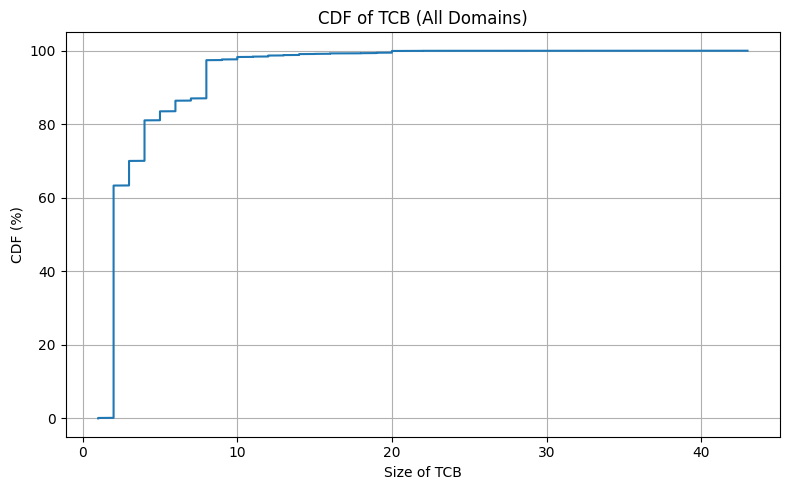

In [162]:
tcb_sorted = np.sort(tcb)
cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)

plt.figure(figsize=(8, 5))
plt.plot(tcb_sorted, cdf * 100)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB (All Domains)")

plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB (All Domains).png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

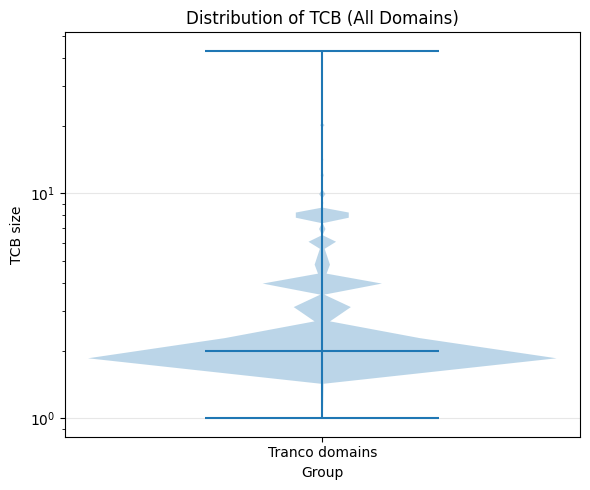

In [163]:
df = resolved_summary_df.copy()

tcb = df["TCB"].dropna().to_numpy()

plt.figure(figsize=(6, 5))

plt.violinplot(
    [tcb],
    showmeans=False,
    showmedians=True
)

plt.xticks([1], ["Tranco domains"])
plt.xlabel("Group")
plt.ylabel("TCB size")
plt.title("Distribution of TCB (All Domains)")

plt.grid(axis="y", alpha=0.3)
plt.yscale("log")
plt.tight_layout()
plt.savefig(fig_dir / "Violin TCB Tranco Domains.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [125]:
tcb = resolved_summary_df["TCB"].dropna().to_numpy()
mean_tcb = np.mean(tcb)
median_tcb = np.median(tcb)

x = 10
tcb = np.array(tcb)

pct_below_or_equal = np.mean(tcb < x) * 100
pct_above = np.mean(tcb > x) * 100


print(f"mean of TCB  {mean_tcb:.2f}")
print(f"median of TCB {median_tcb:.2f}")
print(f"Percentage with TCB < {x}: {pct_below_or_equal:.2f}%")
print(f"Percentage with TCB > {x}: {pct_above:.2f}%")

mean of TCB  3.44
median of TCB 2.00
Percentage with TCB < 10: 97.62%
Percentage with TCB > 10: 1.71%


In [164]:
# maximum
tcb = resolved_summary_df["TCB"]
max_tcb = np.maximum.reduce(tcb)

print(f"Maximum TCB: {max_tcb}")

Maximum TCB: 43


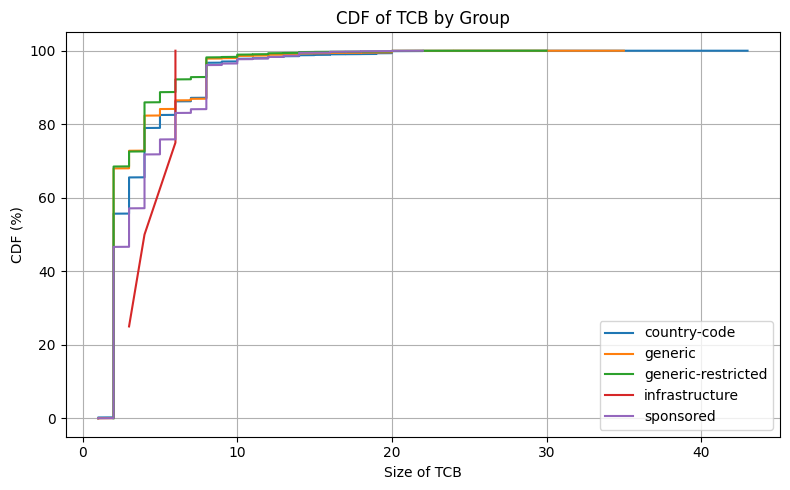

In [165]:
df = resolved_summary_df.copy()


plt.figure(figsize=(8, 5))

for group_name, group_df in df.groupby("type"):
    tcb = group_df["TCB"].dropna().to_numpy()
    
    if len(tcb) == 0:
        continue
    
    tcb_sorted = np.sort(tcb)
    cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)
    
    plt.plot(tcb_sorted, cdf * 100, label=group_name)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB by Group")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB by Group.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

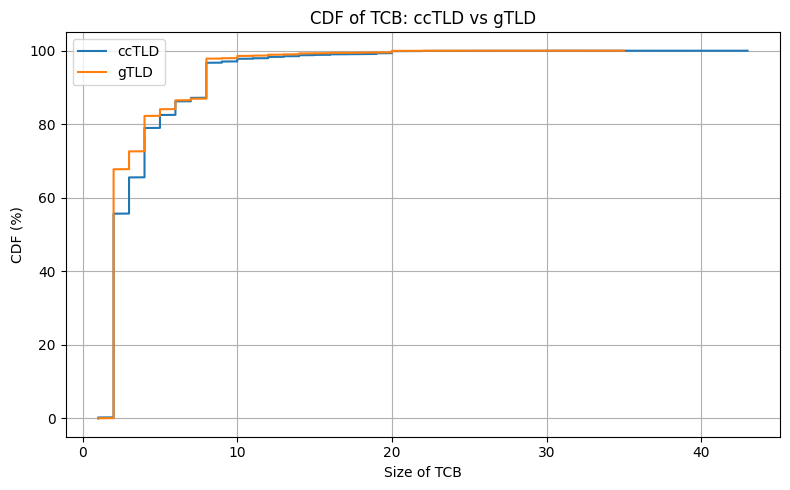

In [135]:
df = resolved_summary_df.copy()

df["TLD_status"] = np.where(
    df["group_code"] == "ccTLD",
    "ccTLD",
    "gTLD"
)

plt.figure(figsize=(8, 5))

for group_name, group_df in df.groupby("TLD_status"):
    tcb = group_df["TCB"].dropna().to_numpy()

    if len(tcb) == 0:
        continue

    tcb_sorted = np.sort(tcb)
    cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)

    plt.plot(tcb_sorted, cdf * 100, label=group_name)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB: ccTLD vs gTLD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB ccTLD vs gTLD.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

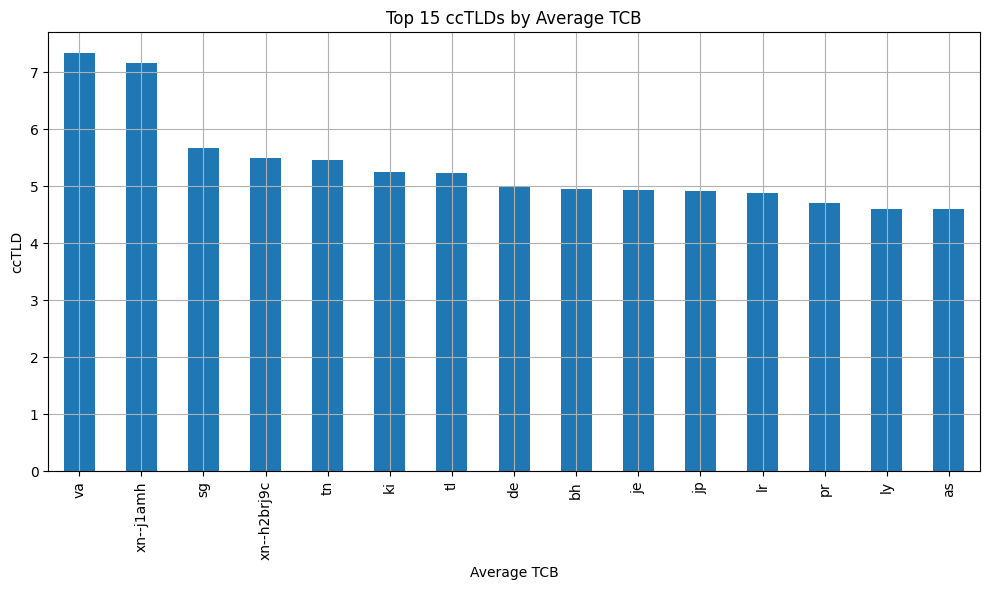

In [145]:
df = resolved_summary_df.copy()

cctld_df = df[df["group_code"] == "ccTLD"]

top15_cctld = (
    cctld_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = top15_cctld.plot(kind="bar", figsize=(10, 6))


plt.xlabel("Average TCB")
plt.grid(True)
plt.ylabel("ccTLD")
plt.title("Top 15 ccTLDs by Average TCB")
plt.tight_layout()
plt.savefig(fig_dir / "Top 15 ccTLDs by Average TCB.png", dpi=300, bbox_inches="tight")
plt.show()

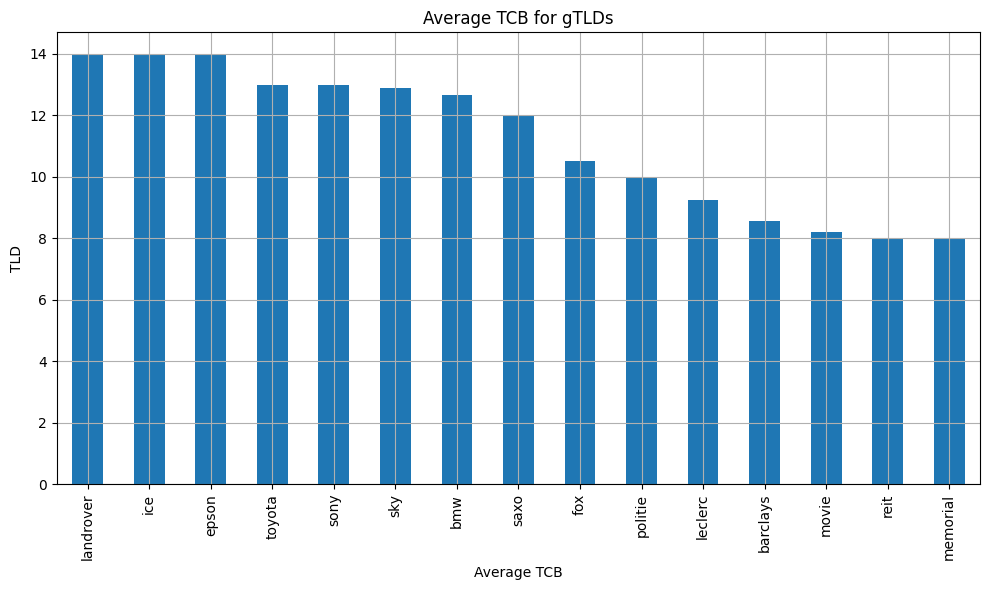

In [147]:
general_df = df[df["group_code"] != "ccTLD"]
general_tld_avg = (
    general_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = general_tld_avg.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Average TCB")
plt.ylabel("TLD")
plt.grid(True)
plt.title("Average TCB for gTLDs")
plt.tight_layout()
plt.savefig(fig_dir / "Average TCB for gTLDs.png", dpi=300, bbox_inches="tight")
plt.show()

#### TCB vs ranking

##### general


In [243]:
plot_df = resolved_summary_df[["domain", "rank", "TCB"]].copy()

# clean
plot_df["rank"] = pd.to_numeric(plot_df["rank"], errors="coerce")
plot_df["TCB"] = pd.to_numeric(plot_df["TCB"], errors="coerce")
plot_df = plot_df.dropna(subset=["rank", "TCB"])


# log-transform rank
plot_df["log_rank"] = np.log10(plot_df["rank"])

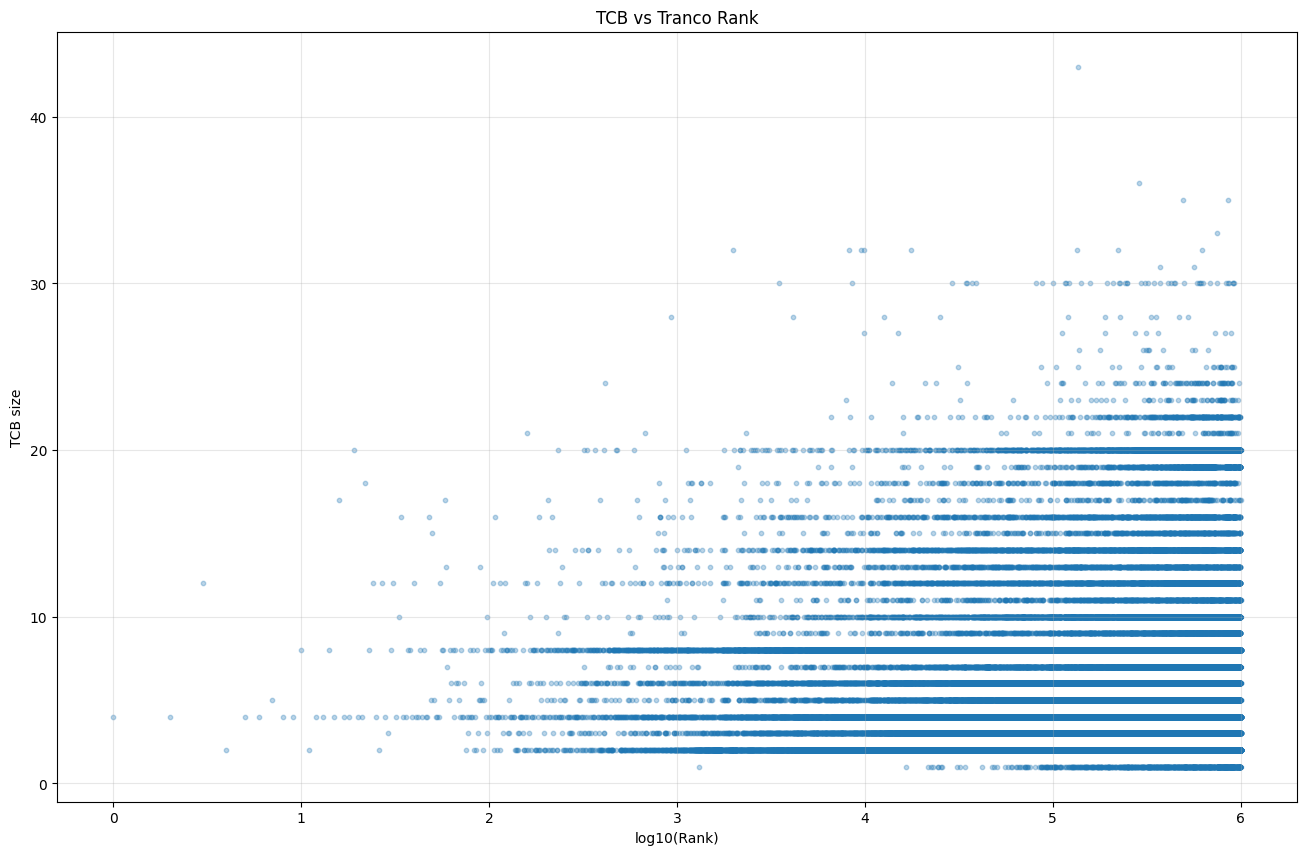

In [244]:
plt.figure(figsize=(16,10))

plt.scatter(
    plot_df["log_rank"],
    plot_df["TCB"],
    alpha=0.3,
    s=10
)

plt.xlabel("log10(Rank)")
plt.ylabel("TCB size")
plt.title("TCB vs Tranco Rank")
plt.grid(True, alpha=0.3)

plt.show()

##### top 1000 vs bottom 1000

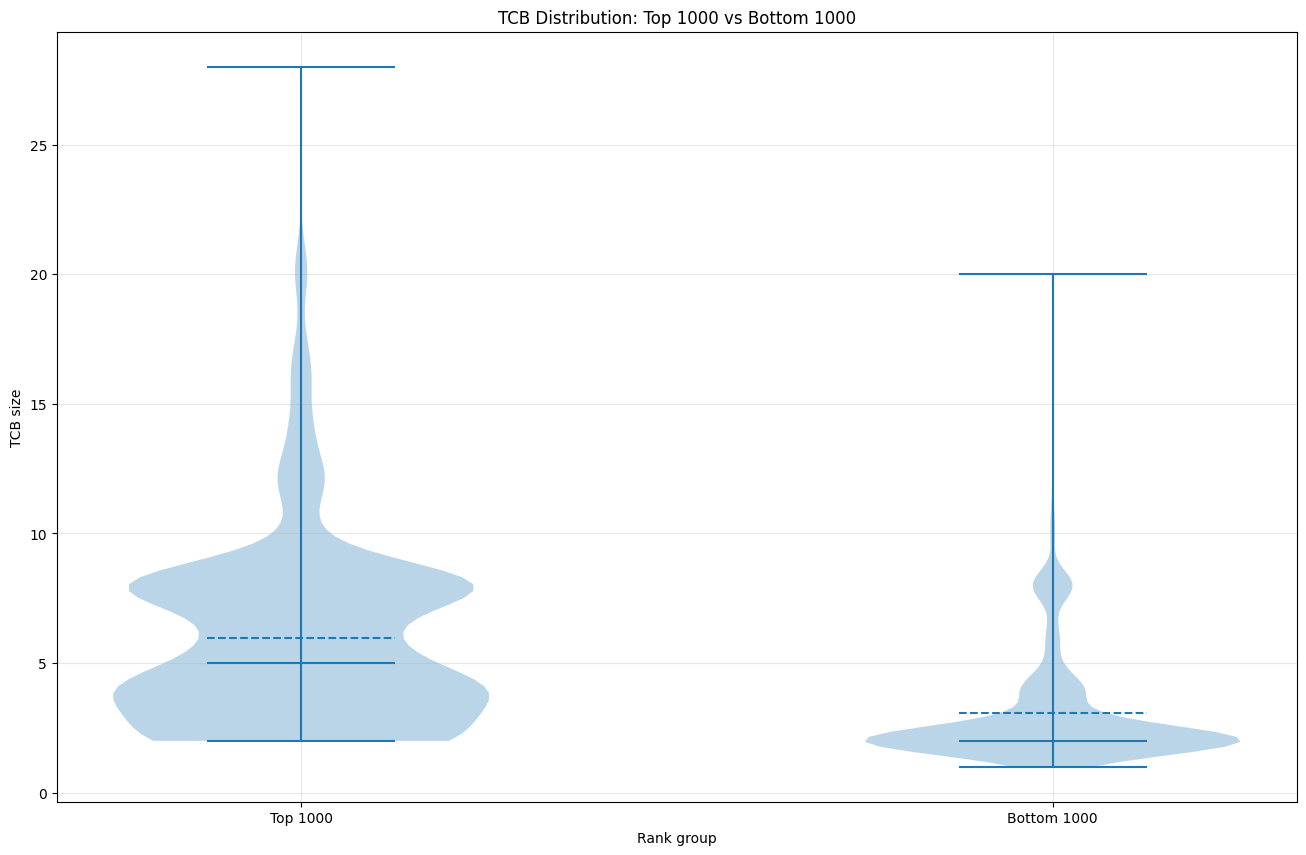

In [245]:
plot_df = resolved_summary_df[["domain", "rank", "TCB"]].copy()

top_1000 = plot_df.nsmallest(1000, "rank").copy()
bottom_1000 = plot_df.nlargest(1000, "rank").copy()

groups = [
    top_1000["TCB"].dropna().to_numpy().ravel(),
    bottom_1000["TCB"].dropna().to_numpy().ravel()
]

labels = ["Top 1000", "Bottom 1000"]

plt.figure(figsize=(16, 10))

parts = plt.violinplot(
    dataset=groups,
    showmeans=True,
    showmedians=True,
  
)

parts["cmeans"].set_linestyle("--")

plt.xticks([1, 2], labels)
plt.xlabel("Rank group")
plt.ylabel("TCB size")
plt.title("TCB Distribution: Top 1000 vs Bottom 1000")
plt.grid(True, alpha=0.3)

plt.show()

##### (top 1000 cTLD vs gTLD) vs   (bottom 1000 cTLD vs gTLD)

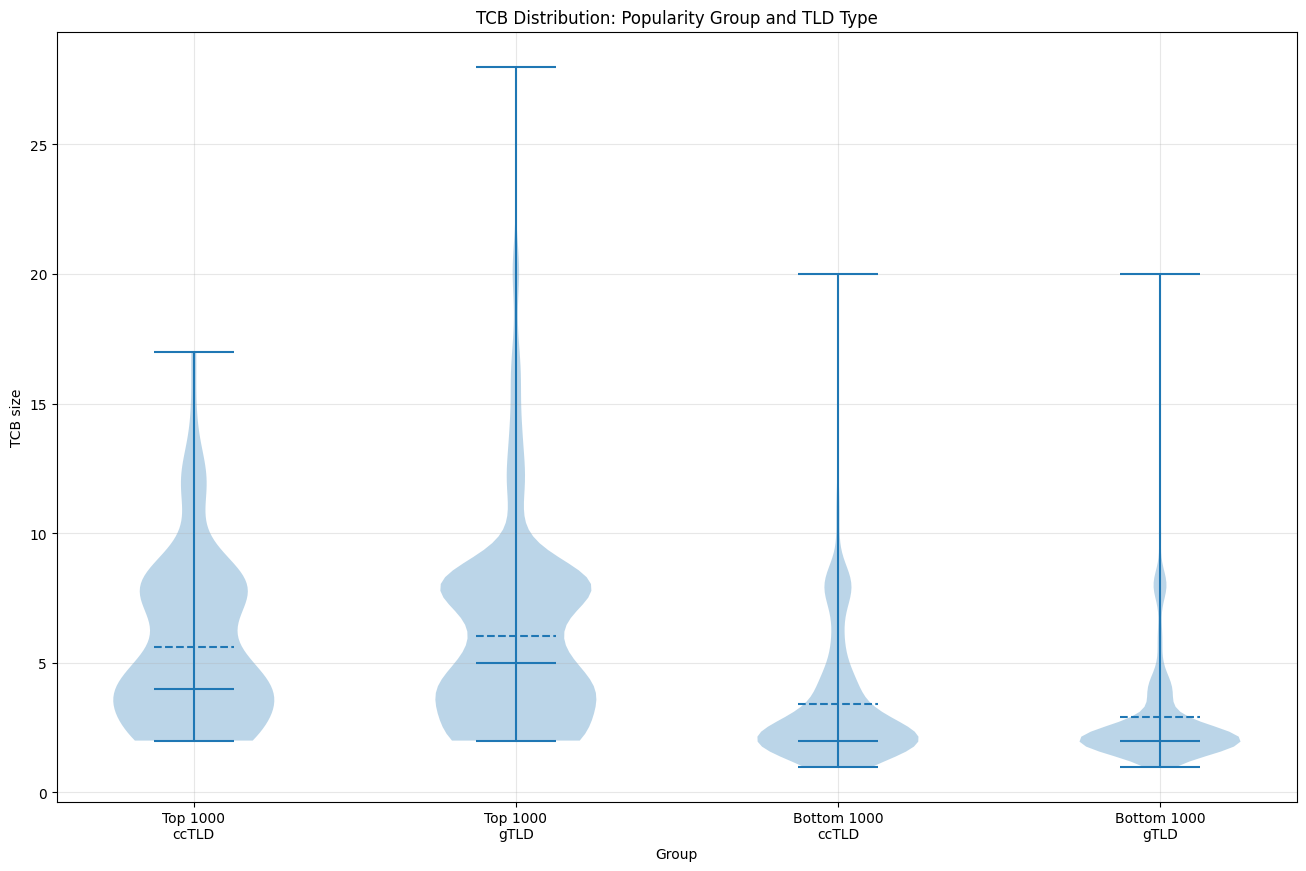

In [246]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

top_1000 = plot_df.nsmallest(1000, "rank").copy()
bottom_1000 = plot_df.nlargest(1000, "rank").copy()

top_1000["popularity_group"] = "Top 1000"
bottom_1000["popularity_group"] = "Bottom 1000"

compare_df = pd.concat([top_1000, bottom_1000], ignore_index=True)

groups = []
labels = []

for pop_group in ["Top 1000", "Bottom 1000"]:
    for tld_group in ["ccTLD", "gTLD"]:
        values = compare_df[
            (compare_df["popularity_group"] == pop_group) &
            (compare_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        labels.append(f"{pop_group}\n{tld_group}")

plt.figure(figsize=(16, 10))

parts = plt.violinplot(
    dataset=groups,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_linestyle("--")

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Group")
plt.ylabel("TCB size")
plt.title("TCB Distribution: Popularity Group and TLD Type")
plt.grid(True, alpha=0.3)

plt.show()


##### (top 10000 cTLD vs gTLD) vs   (bottom 10000cTLD vs gTLD)

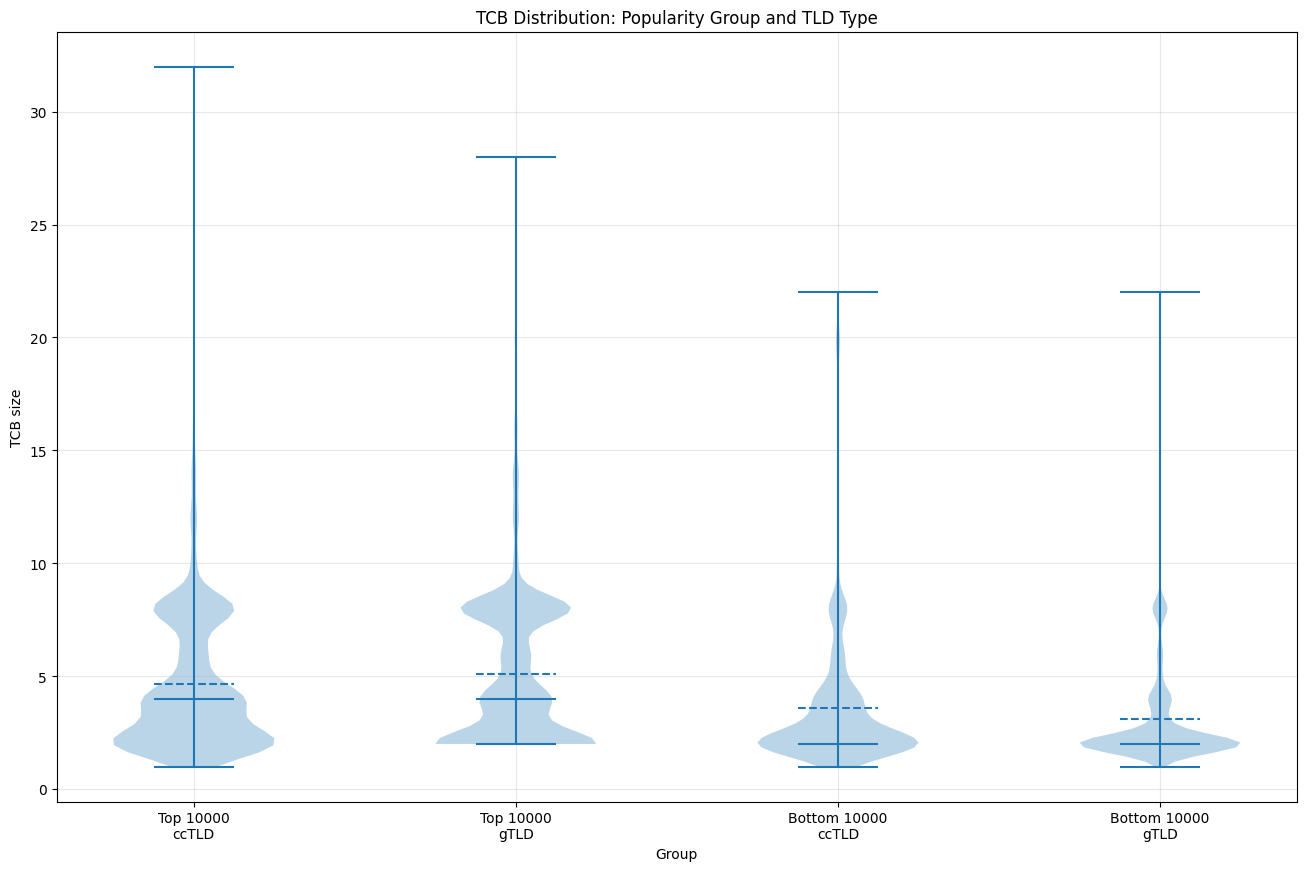

In [248]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

top_10000 = plot_df.nsmallest(10000, "rank").copy()
bottom_10000 = plot_df.nlargest(10000, "rank").copy()

top_10000["popularity_group"] = "Top 10000"
bottom_10000["popularity_group"] = "Bottom 10000"

compare_df = pd.concat([top_10000, bottom_10000], ignore_index=True)

groups = []
labels = []

for pop_group in ["Top 10000", "Bottom 10000"]:
    for tld_group in ["ccTLD", "gTLD"]:
        values = compare_df[
            (compare_df["popularity_group"] == pop_group) &
            (compare_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        labels.append(f"{pop_group}\n{tld_group}")

plt.figure(figsize=(16, 10))

parts = plt.violinplot(
    dataset=groups,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_linestyle("--")

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Group")
plt.ylabel("TCB size")
plt.title("TCB Distribution: Popularity Group and TLD Type")
plt.grid(True, alpha=0.3)

plt.show()

Trends in the 100K

In [249]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)


plot_df["rank"] = pd.to_numeric(plot_df["rank"], errors="coerce")
plot_df["TCB"] = pd.to_numeric(plot_df["TCB"], errors="coerce")
plot_df = plot_df.dropna(subset=["rank", "TCB", "group_code"])


# keep top 100k only
plot_df = plot_df[(plot_df["rank"] >= 1) & (plot_df["rank"] <= 100000)]

# create 10 rank groups of 10k
plot_df["rank_bin"] = ((plot_df["rank"] - 1) // 10000) + 1

plot_df["rank_bin_label"] = plot_df["rank_bin"].apply(
    lambda x: f"{(x-1)*10000 + 1}-{x*10000}"
)

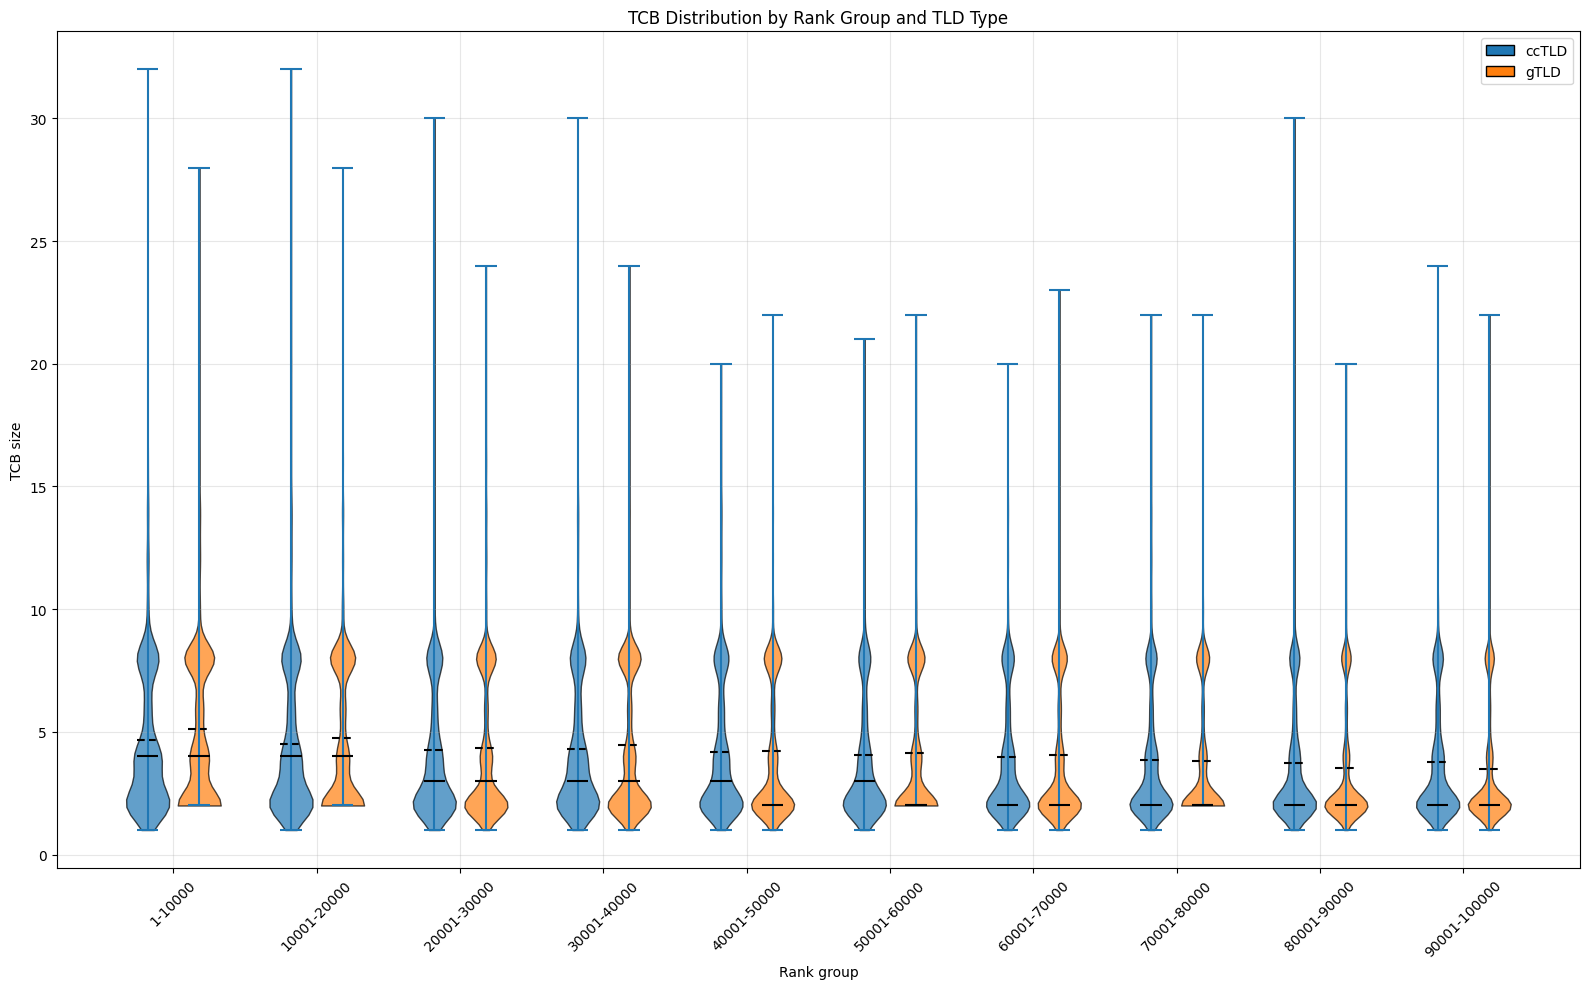

In [250]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = plot_df[
            (plot_df["rank_bin"] == i) &
            (plot_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{(i-1)*10000 + 1}-{i*10000}" for i in range(1, 11)],
    rotation=45
)

ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("TCB Distribution by Rank Group and TLD Type")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)

plt.tight_layout()
plt.show()

##### Trends in the least  100K

In [251]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

plot_df["rank"] = pd.to_numeric(plot_df["rank"], errors="coerce")
plot_df["TCB"] = pd.to_numeric(plot_df["TCB"], errors="coerce")
plot_df = plot_df.dropna(subset=["rank", "TCB", "group_code"])



# last 100k ranks
plot_df = plot_df[(plot_df["rank"] >= 900000) & (plot_df["rank"] <= 1000000)]

# create 10 groups of 10k
plot_df["rank_bin"] = ((plot_df["rank"] - 900000) // 10000) + 1

plot_df["rank_bin_label"] = plot_df["rank_bin"].apply(
    lambda x: f"{900000 + (x-1)*10000}-{900000 + x*10000 - 1}"
)

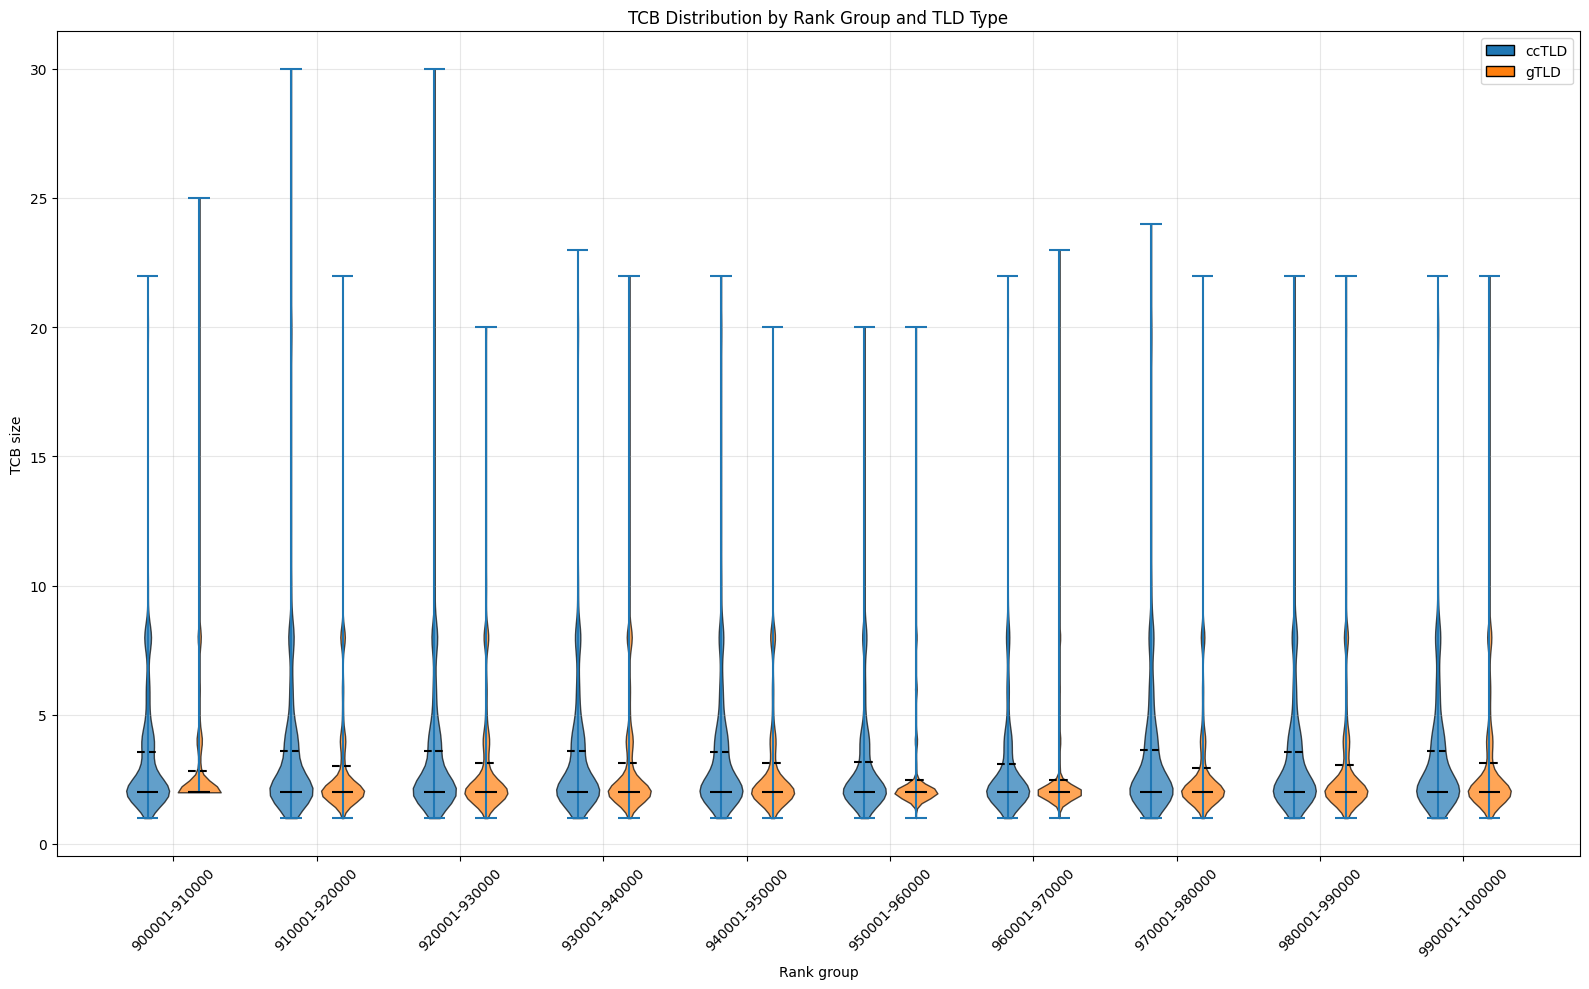

In [252]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = plot_df[
            (plot_df["rank_bin"] == i) &
            (plot_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{900001 + (i-1)*10000}-{900000 + i*10000}" for i in range(1, 11)],
    rotation=45
)
ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("TCB Distribution by Rank Group and TLD Type")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)

plt.tight_layout()
plt.show()

##### Example

In [45]:
pd.set_option("display.max_colwidth", None)
resolved_summary_df[resolved_summary_df["domain"] == "utwente.nl"]

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,tld,type
926401,utwente.nl,1,1,3,1.0,3,"[ns2.utwente.nl, ns3.utwente.nl, ns1.utwente.nl]","[{'name_server_count': 1, 'name_servers': ['ns2.utwente.nl'], 'start_domain': 'utwente.nl'}, {'name_server_count': 1, 'name_servers': ['ns3.utwente.nl'], 'start_domain': 'utwente.nl'}, {'name_server_count': 1, 'name_servers': ['ns1.utwente.nl'], 'start_domain': 'utwente.nl'}]","[{'source': 'utwente.nl', 'target_zone': None, 'via_nameservers': ['ns2.utwente.nl', 'ns3.utwente.nl', 'ns1.utwente.nl']}]",ccTLD,nl,country-code


In [48]:
pd.set_option("display.max_colwidth", None)
resolved_summary_df[resolved_summary_df["domain"] == "pwcedge-sbs-innov-lab.com"]

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,tld,type
16,pwcedge-sbs-innov-lab.com,1,2,7,1.571429,8,"[ns-460.awsdns-57.com, ns-1017.awsdns-63.net, ns-1424.awsdns-50.org, ns-1840.awsdns-38.co.uk, g-ns-1834.awsdns-38.co.uk, g-ns-934.awsdns-38.co.uk, g-ns-358.awsdns-38.co.uk, g-ns-1513.awsdns-38.co.uk]","[{'name_server_count': 1, 'name_servers': ['ns-460.awsdns-57.com'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 1, 'name_servers': ['ns-1017.awsdns-63.net'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 1, 'name_servers': ['ns-1424.awsdns-50.org'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-1834.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-934.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-358.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-1513.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}]","[{'source': 'pwcedge-sbs-innov-lab.com', 'target_zone': None, 'via_nameservers': ['ns-460.awsdns-57.com', 'ns-1017.awsdns-63.net', 'ns-1424.awsdns-50.org']}, {'source': 'pwcedge-sbs-innov-lab.com', 'target_zone': 'awsdns-38.co.uk', 'via_nameservers': ['ns-1840.awsdns-38.co.uk']}, {'source': 'awsdns-38.co.uk', 'target_zone': None, 'via_nameservers': ['g-ns-1834.awsdns-38.co.uk', 'g-ns-934.awsdns-38.co.uk', 'g-ns-358.awsdns-38.co.uk', 'g-ns-1513.awsdns-38.co.uk']}]",gTLD,com,generic


In [50]:
pd.set_option("display.max_colwidth", None)
resolved_summary_df[resolved_summary_df["domain"] == "villanova.edu"]

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,tld,type
945821,villanova.edu,1,3,12,2.333333,10,"[dnsauth3.sys.gtei.net, dnsauth2.sys.gtei.net, ns5.villanova.edu, ns4.villanova.edu, ns1.net.pennren.net, ns2.net.pennren.net, dns2.firstlight.net, dns1.firstlight.net, cns1.firstlight.net, cns2.firstlight.net]","[{'name_server_count': 1, 'name_servers': ['dnsauth3.sys.gtei.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 1, 'name_servers': ['dnsauth2.sys.gtei.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 1, 'name_servers': ['ns5.villanova.edu'], 'start_domain': 'villanova.edu'}, {'name_server_count': 1, 'name_servers': ['ns4.villanova.edu'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns2.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns2.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns1.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns1.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns2.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns2.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns1.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns1.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}]","[{'source': 'villanova.edu', 'target_zone': None, 'via_nameservers': ['dnsauth3.sys.gtei.net', 'dnsauth2.sys.gtei.net', 'ns5.villanova.edu', 'ns4.villanova.edu']}, {'source': 'villanova.edu', 'target_zone': 'net.pennren.net', 'via_nameservers': ['ns1.net.pennren.net', 'ns2.net.pennren.net']}, {'source': 'net.pennren.net', 'target_zone': 'firstlight.net', 'via_nameservers': ['dns2.firstlight.net', 'dns1.firstlight.net']}, {'source': 'firstlight.net', 'target_zone': None, 'via_nameservers': ['cns1.firstlight.net', 'cns2.firstlight.net']}]",sponTLD,edu,sponsored


In [85]:
domain_with_parent.head()

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,parent,short_path_size_via_parent,long_path_size_via_parent,available_paths_via_parent,average_path_size_via_parent,parent_TCB,TCB_with_parent,all_parent_unique_ns,parent_path_rows
0,apostille.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare.com]","[{'domain': 'apostille.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['apostille.mygov.bd', 'melina.ns.cloudflare.com']}, {'domain': 'apostille.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['apostille.mygov.bd', 'nile.ns.cloudflare.com']}]","[{'side': 'child', 'source': 'apostille.mygov.bd', 'target_zone': None, 'via_nameservers': ['melina.ns.cloudflare.com', 'nile.ns.cloudflare.com']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': None, 'via_nameservers': ['ns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': 'bcc.gov.bd', 'via_nameservers': ['dns2.bcc.gov.bd', 'dns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'bcc.gov.bd', 'target_zone': None, 'via_nameservers': ['ns2.bcc.gov.bd', 'ns1.bcc.gov.bd']}]",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov.bd, ns2.bcc.gov.bd]","[{'domain': 'mygov.bd', 'name_server_count': 1, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}]"
1,www.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare.com]","[{'domain': 'www.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['www.mygov.bd', 'melina.ns.cloudflare.com']}, {'domain': 'www.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['www.mygov.bd', 'nile.ns.cloudflare.com']}]","[{'side': 'child', 'source': 'www.mygov.bd', 'target_zone': None, 'via_nameservers': ['melina.ns.cloudflare.com', 'nile.ns.cloudflare.com']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': None, 'via_nameservers': ['ns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': 'bcc.gov.bd', 'via_nameservers': ['dns2.bcc.gov.bd', 'dns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'bcc.gov.bd', 'target_zone': None, 'via_nameservers': ['ns2.bcc.gov.bd', 'ns1.bcc.gov.bd']}]",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov.bd, ns2.bcc.gov.bd]","[{'domain': 'mygov.bd', 'name_server_count': 1, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}]"


##### Other Questions


#### With parent


In [86]:
# create a column on dataframe domain_with_parent with value  "jnsde"
domain_with_parent["group_code"] = "country-code"




In [87]:
with_parent_resolved_summary_df = domain_with_parent.merge(
    categorized_names_df[["domain", "tld", "type"]],
    on="domain",
    how="left"
)

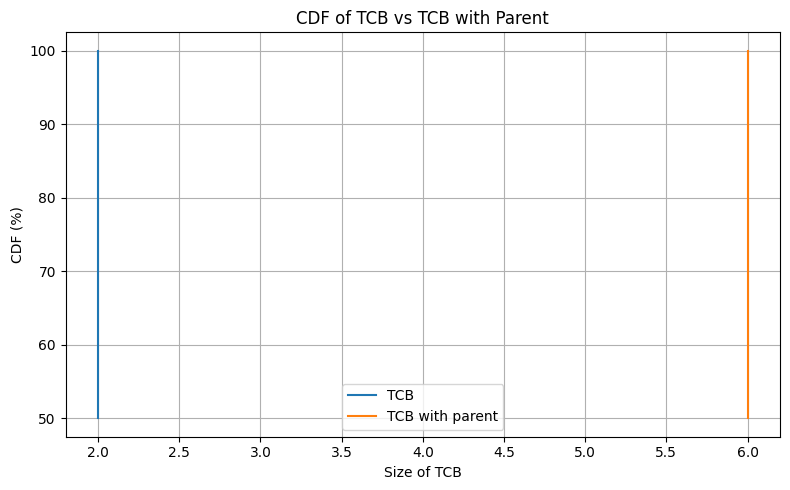

In [89]:
df = with_parent_resolved_summary_df.copy()

# keep only rows where both exist
df = df.dropna(subset=["TCB", "TCB_with_parent"])

plt.figure(figsize=(8, 5))

for col, label in [("TCB", "TCB"), ("TCB_with_parent", "TCB with parent")]:
    values = np.sort(df[col].to_numpy())
    cdf = np.arange(1, len(values) + 1) / len(values)

    plt.plot(values, cdf * 100, label=label)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB vs TCB with Parent")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(fig_dir / "CDF_TCB_vs_TCB_with_parent.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### TCB  TLD Distribution.